# Task 1: Data Cleaning & Visualization

**Thiranex Virtual Internship — Telco Customer Churn Dataset**

This notebook documents the end-to-end data quality audit, cleaning pipeline, and visual storytelling for Task 1.

> **Google Colab:** Upload the entire `Task 1` folder to Google Drive at `MyDrive/Thiranex/Task 1`, then run all cells. Drive will be mounted automatically.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- Environment setup (Local Jupyter + Google Colab) ---
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q pandas numpy scikit-learn matplotlib seaborn
    from google.colab import drive
    drive.mount("/content/drive")

    candidates = [
        Path("/content/drive/MyDrive/Thiranex/Task 1"),
        Path("/content/drive/MyDrive/Task 1"),
        Path("/content/Thiranex/Task 1"),
        Path("/content/Task 1"),
    ]
    PROJECT_ROOT = next((p for p in candidates if p.exists()), None)
    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "Upload Task 1 to Google Drive at MyDrive/Thiranex/Task 1 "
            "or clone the repo to /content/Thiranex/Task 1"
        )
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

import os
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_cleaning import audit_dataset, classify_missingness, run_cleaning_pipeline
from visualization import generate_all_task1_figures

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "task1_data.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "task1_cleaned.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print(f"Runtime: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data exists: {RAW_PATH.exists()}")

C:\Users\Syed Imad Muzaffar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Runtime: Local
Project root: C:\Users\Syed Imad Muzaffar\Downloads\Thiranex\Task 1
Raw data exists: True


## 1. Initial Data Audit

Before any transformation, we validate file integrity, schema, missingness, and duplicate records.

In [2]:
raw_df = pd.read_csv(RAW_PATH)

print("Shape:", raw_df.shape)
display(raw_df.head())
raw_df.info()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
audit_before = audit_dataset(raw_df)

print("Explicit missing values:\n", pd.Series(audit_before["missing_values"]))
print("\nHidden missing in strings:", audit_before["hidden_missing_in_strings"])
print("Duplicate rows:", audit_before["duplicate_rows"])
print("Type issues:", audit_before["type_issues"])

Explicit missing values:
 Series([], dtype: object)

Hidden missing in strings: {'TotalCharges': 11}
Duplicate rows: 0
Type issues: [{'column': 'TotalCharges', 'issue': 'stored_as_string', 'invalid_or_blank_values': 11}]


### Missingness Mechanism: `TotalCharges`

Although `df.isna().sum()` reports zero nulls, **11 rows** contain whitespace in `TotalCharges`. All correspond to `tenure = 0` (brand-new customers).

- **Classification:** MNAR — missingness is explained by tenure.
- **Imputation:** `TotalCharges = MonthlyCharges` for tenure-0 customers.

In [4]:
mechanism = classify_missingness(raw_df, "TotalCharges")
print(f"TotalCharges missingness mechanism: {mechanism}")

bad_mask = pd.to_numeric(raw_df["TotalCharges"].astype(str).str.strip(), errors="coerce").isna()
display(raw_df.loc[bad_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

TotalCharges missingness mechanism: MNAR


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 2. Cleaning Pipeline

The reusable pipeline in `src/data_cleaning.py` performs whitespace normalization, MNAR imputation, and IQR outlier clipping.

In [5]:
raw_df, cleaned_df, audit_before, pipeline_log = run_cleaning_pipeline(
    RAW_PATH,
    PROCESSED_PATH,
    outlier_method="iqr",
)

print("Cleaning steps:", pipeline_log["cleaning"]["steps"])
print("Outlier rows clipped:", pipeline_log["cleaning"]["outlier_rows_clipped"])
print("\nCleaned shape:", cleaned_df.shape)
print("Remaining nulls:", cleaned_df.isna().sum().sum())
cleaned_df.info()

Cleaning steps: ['stripped_whitespace_and_blank_strings_to_nan', 'converted_total_charges_numeric_imputed_mnar', 'clipped_outliers_iqr_1.5']
Outlier rows clipped: 0

Cleaned shape: (7043, 22)
Remaining nulls: 0
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-nul

In [6]:
print("=== Before vs After: Numeric Summary ===")
summary_before = raw_df.assign(
    TotalCharges=pd.to_numeric(raw_df["TotalCharges"].astype(str).str.strip(), errors="coerce")
)[["tenure", "MonthlyCharges", "TotalCharges"]].describe()
summary_after = cleaned_df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

display(summary_before)
display(summary_after)

=== Before vs After: Numeric Summary ===


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992
std,24.559481,30.090047,2266.730170
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


## 3. Visual Storytelling

Publication-quality figures (300 DPI) are exported to `reports/figures/`.

In [7]:
saved_figures = generate_all_task1_figures(raw_df, cleaned_df, FIGURES_DIR)
for fig_path in saved_figures:
    print(f"Saved: {fig_path.name}")

Saved: 01_missing_heatmap_before.png
Saved: 02_missing_heatmap_after.png
Saved: 03_totalcharges_distribution_shift.png
Saved: 04_univariate_numeric_distributions.png
Saved: 05_monthlycharges_by_contract.png
Saved: 06_tenure_by_churn.png
Saved: 07_correlation_heatmap.png


01_missing_heatmap_before.png


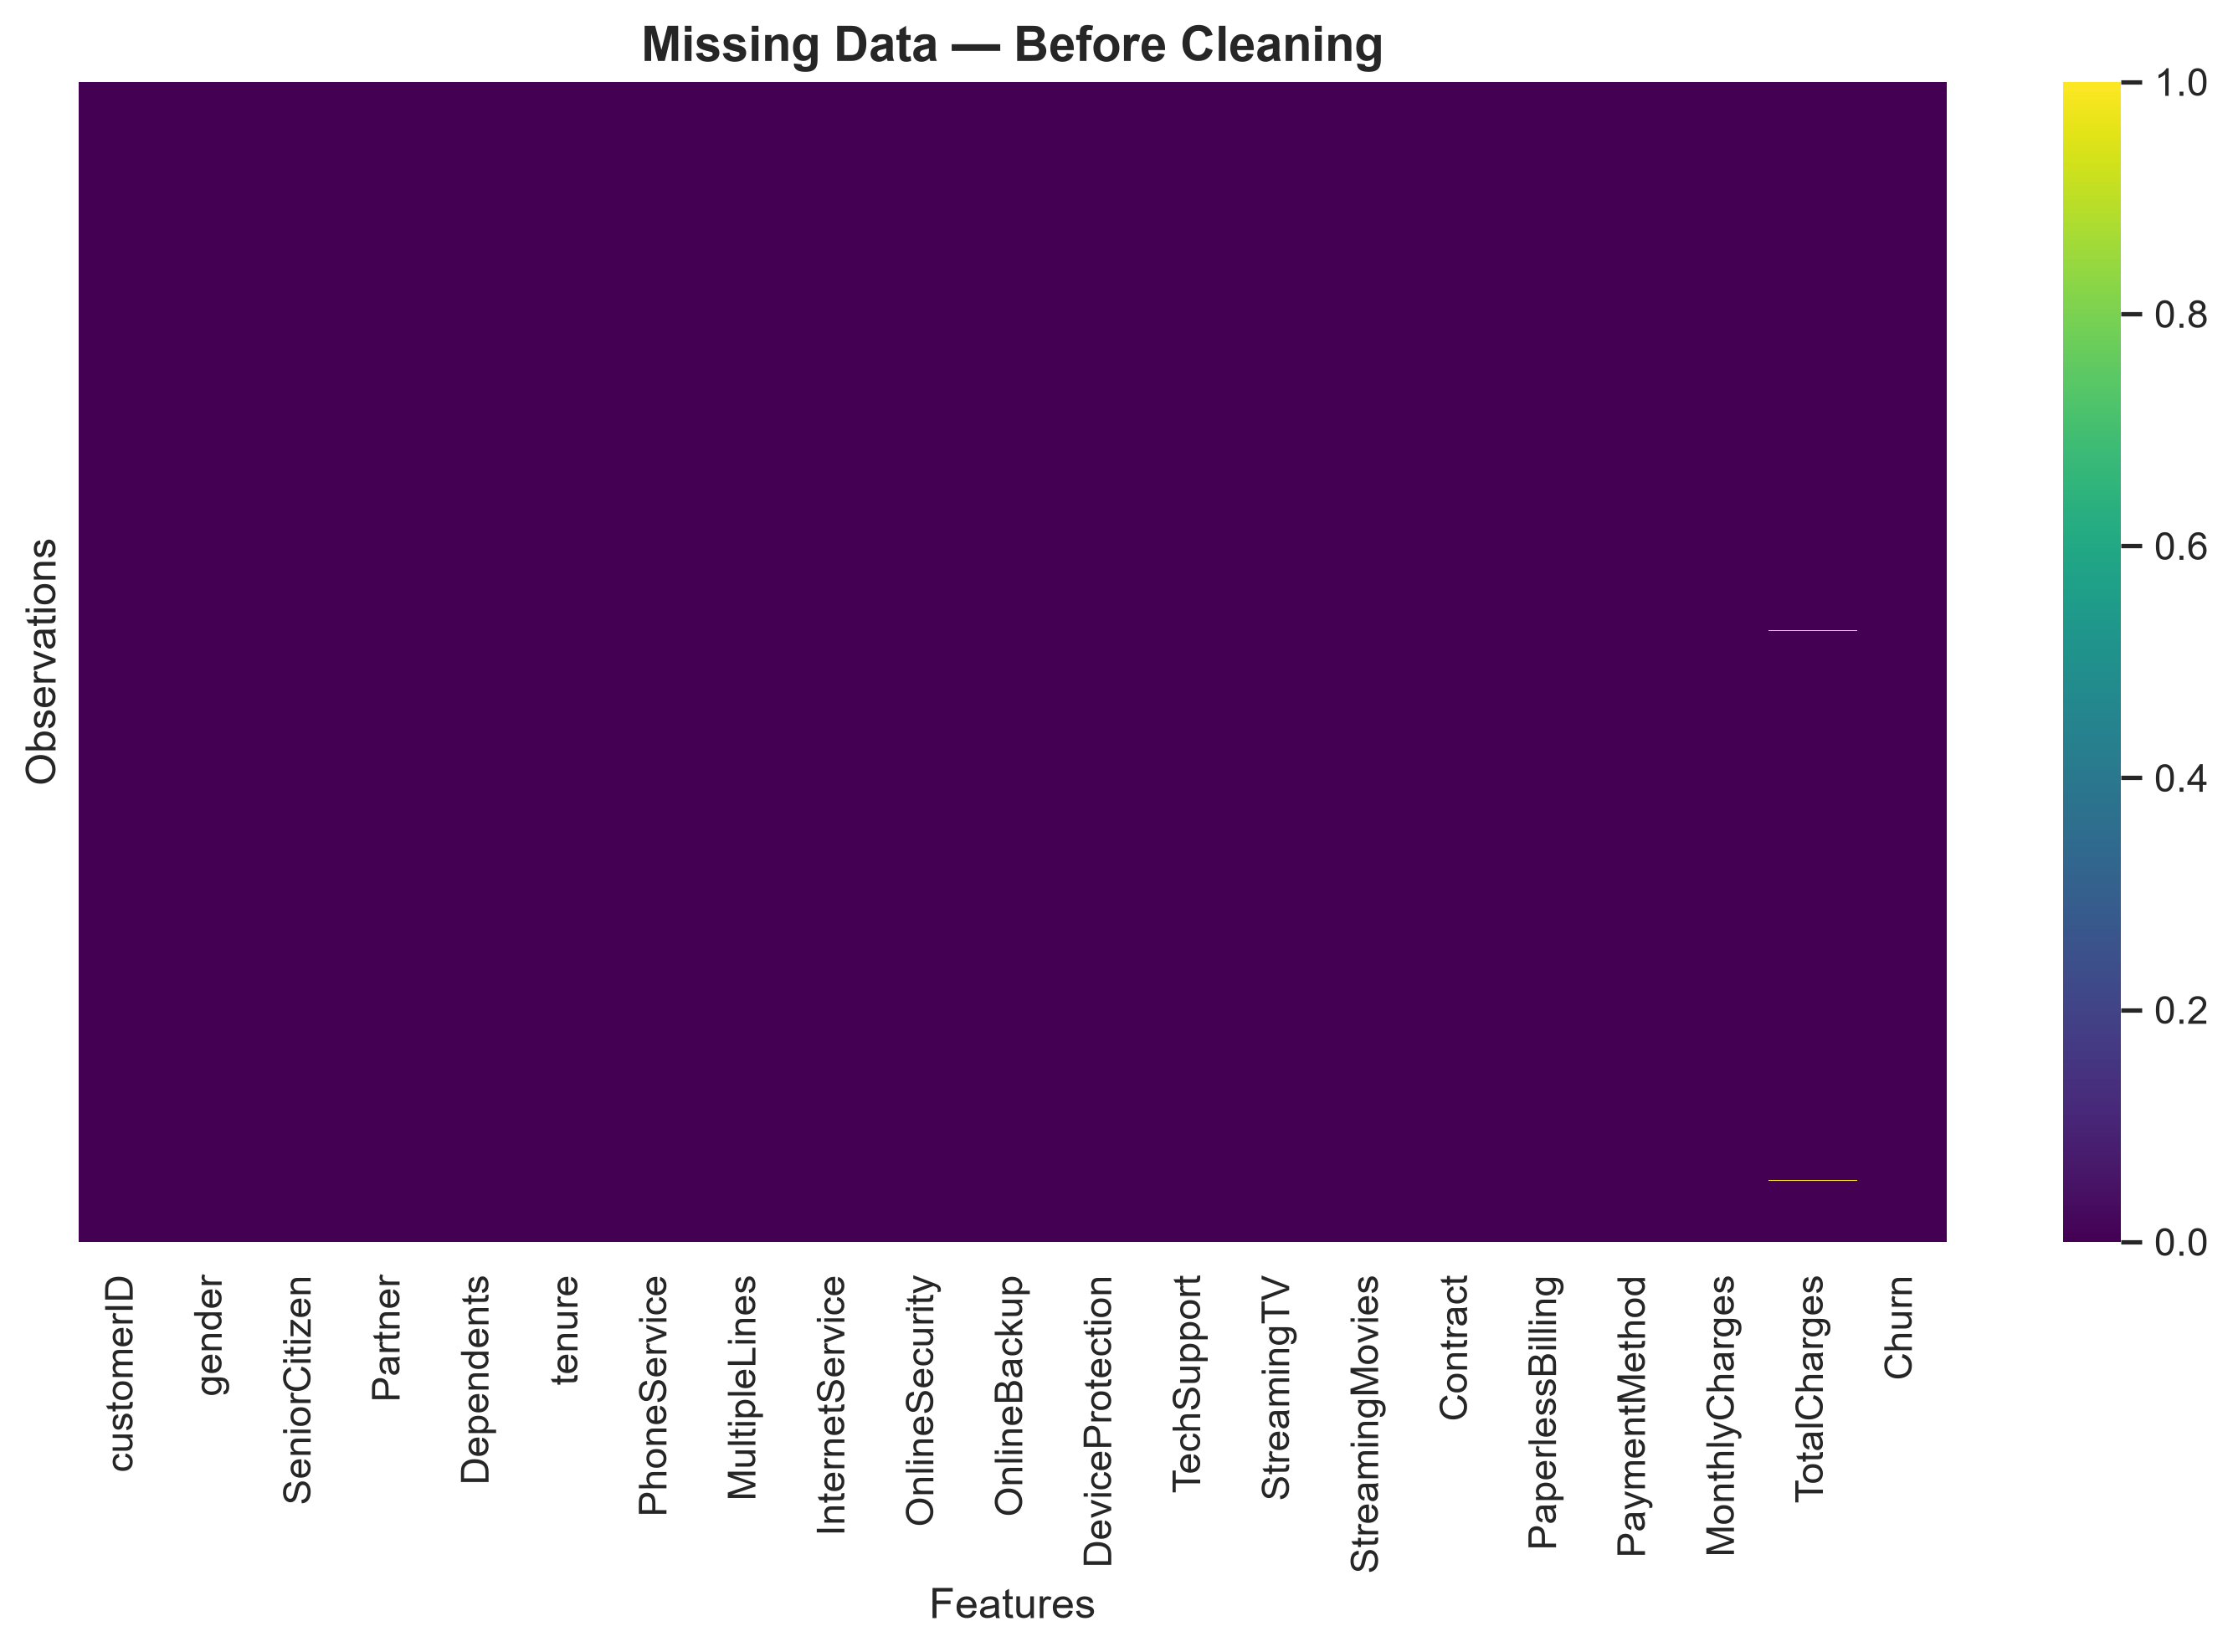

02_missing_heatmap_after.png


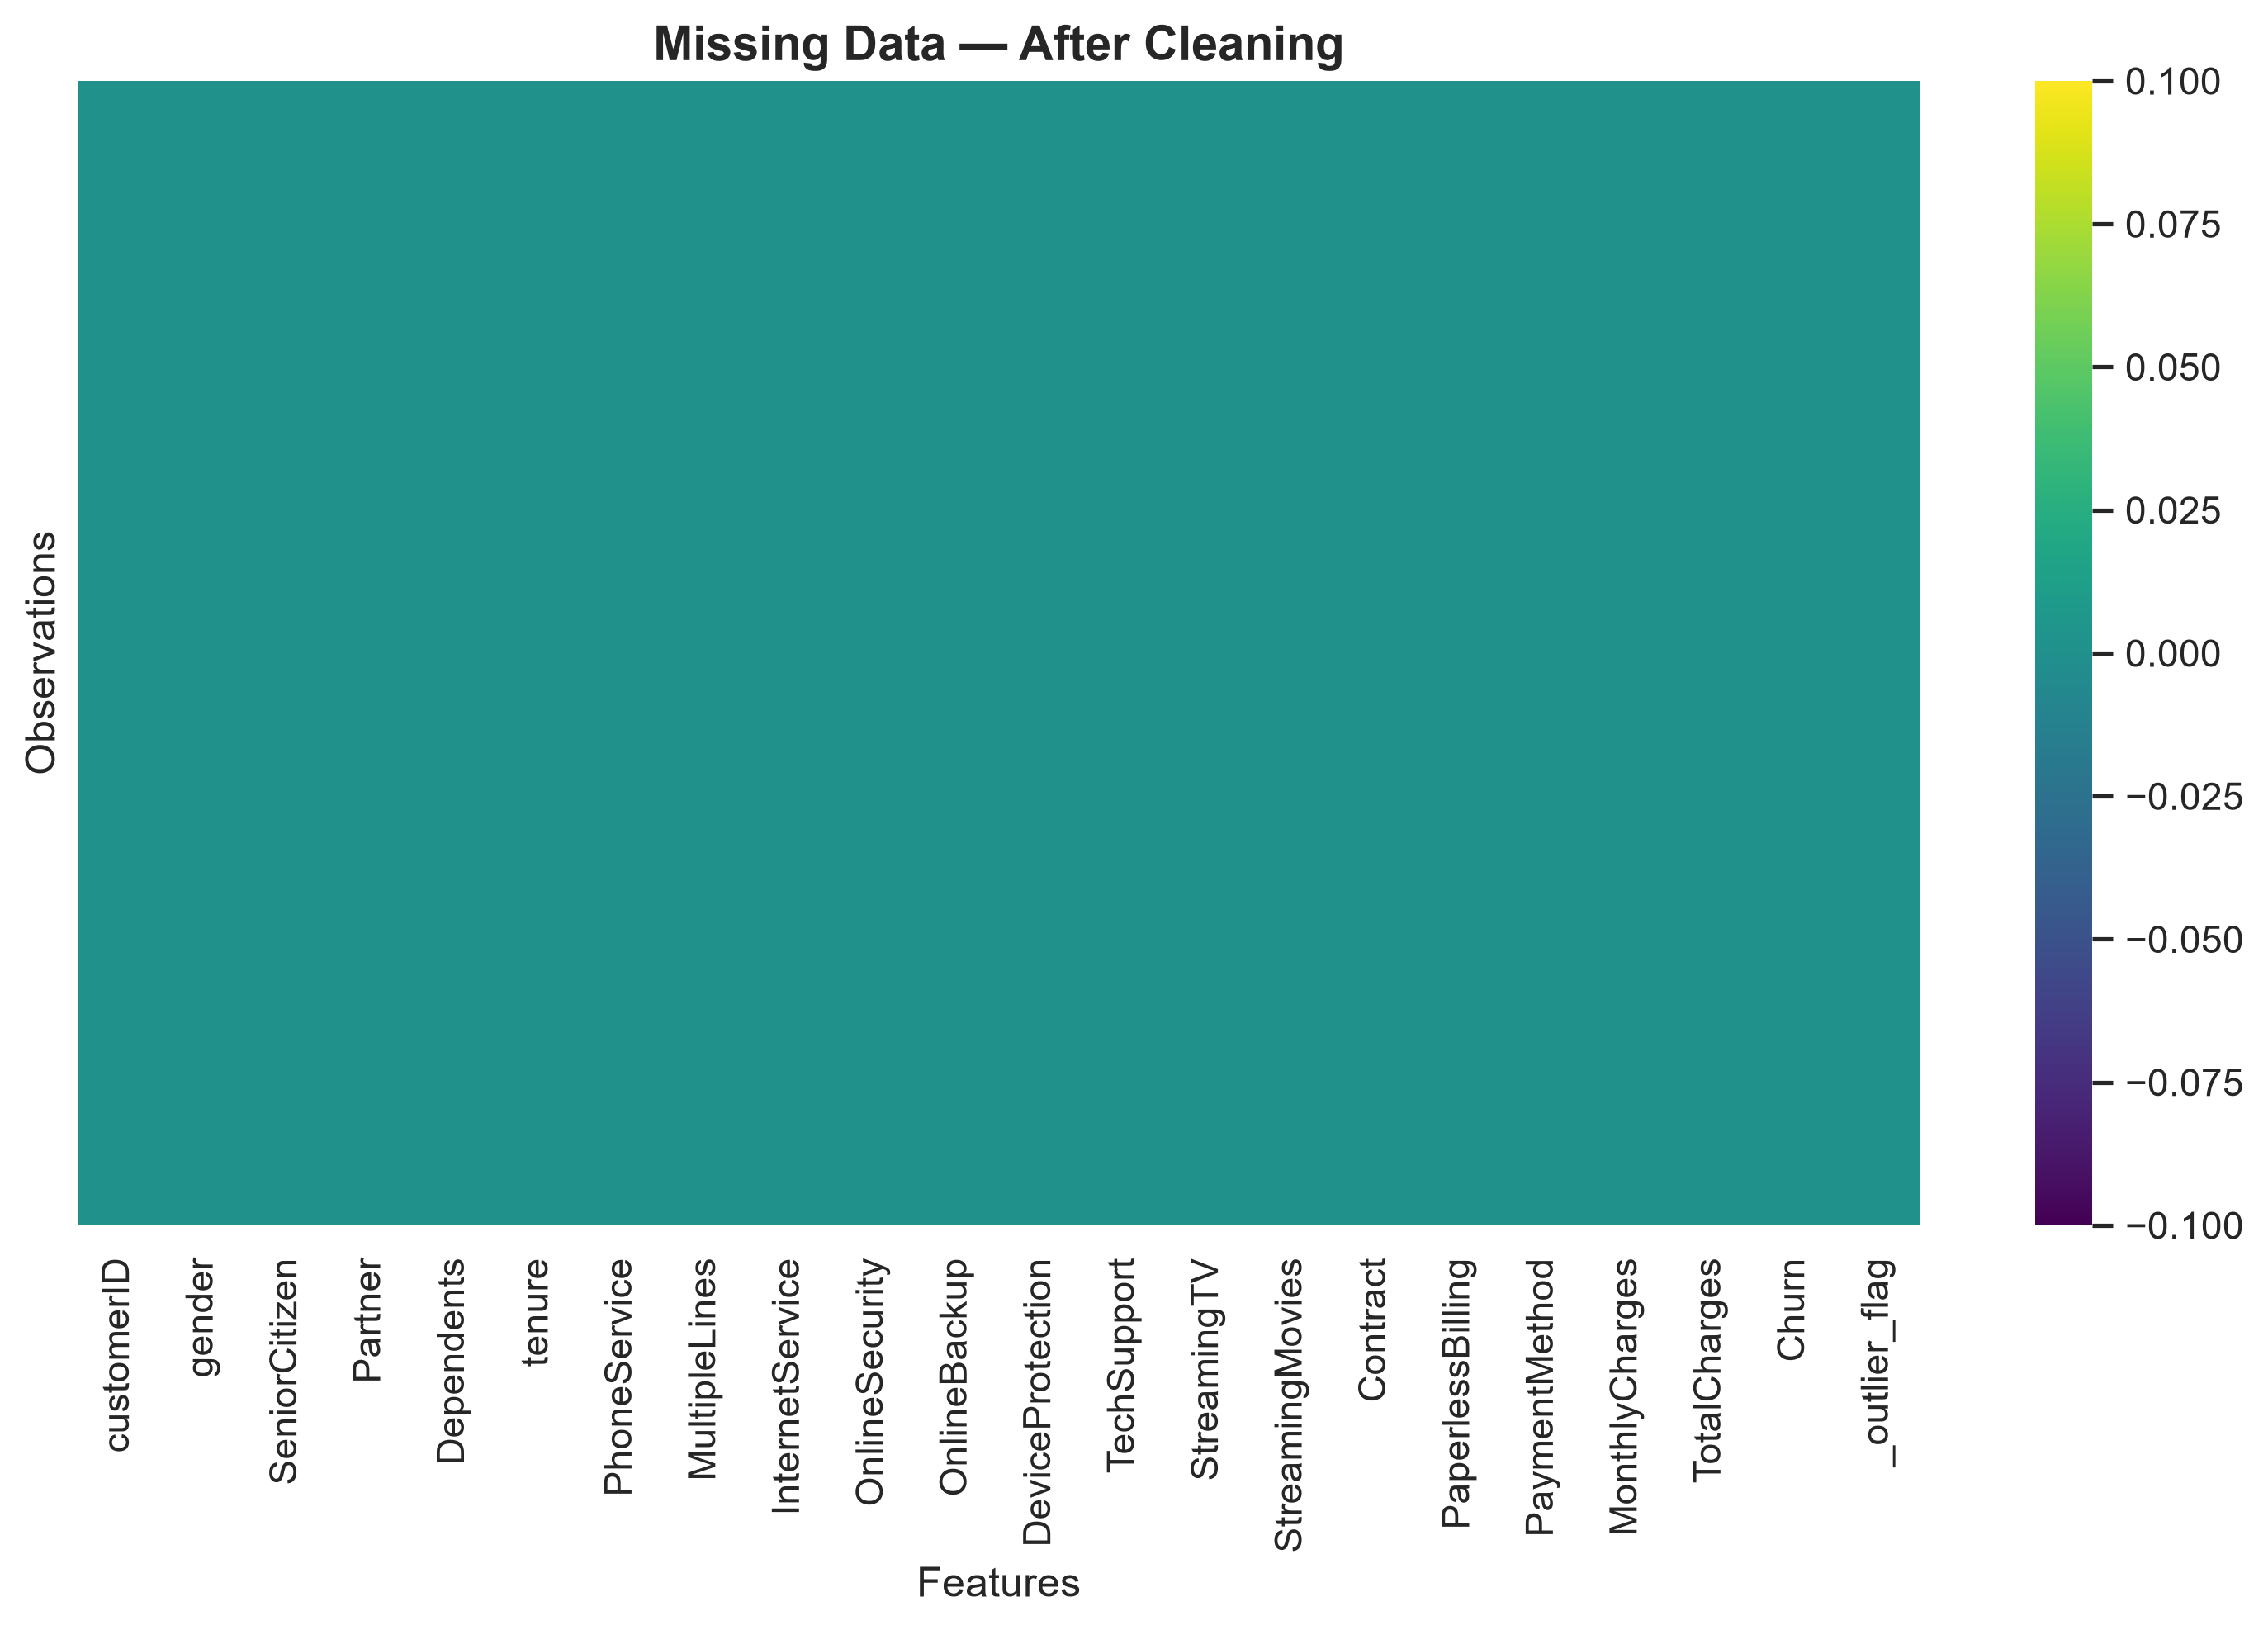

03_totalcharges_distribution_shift.png


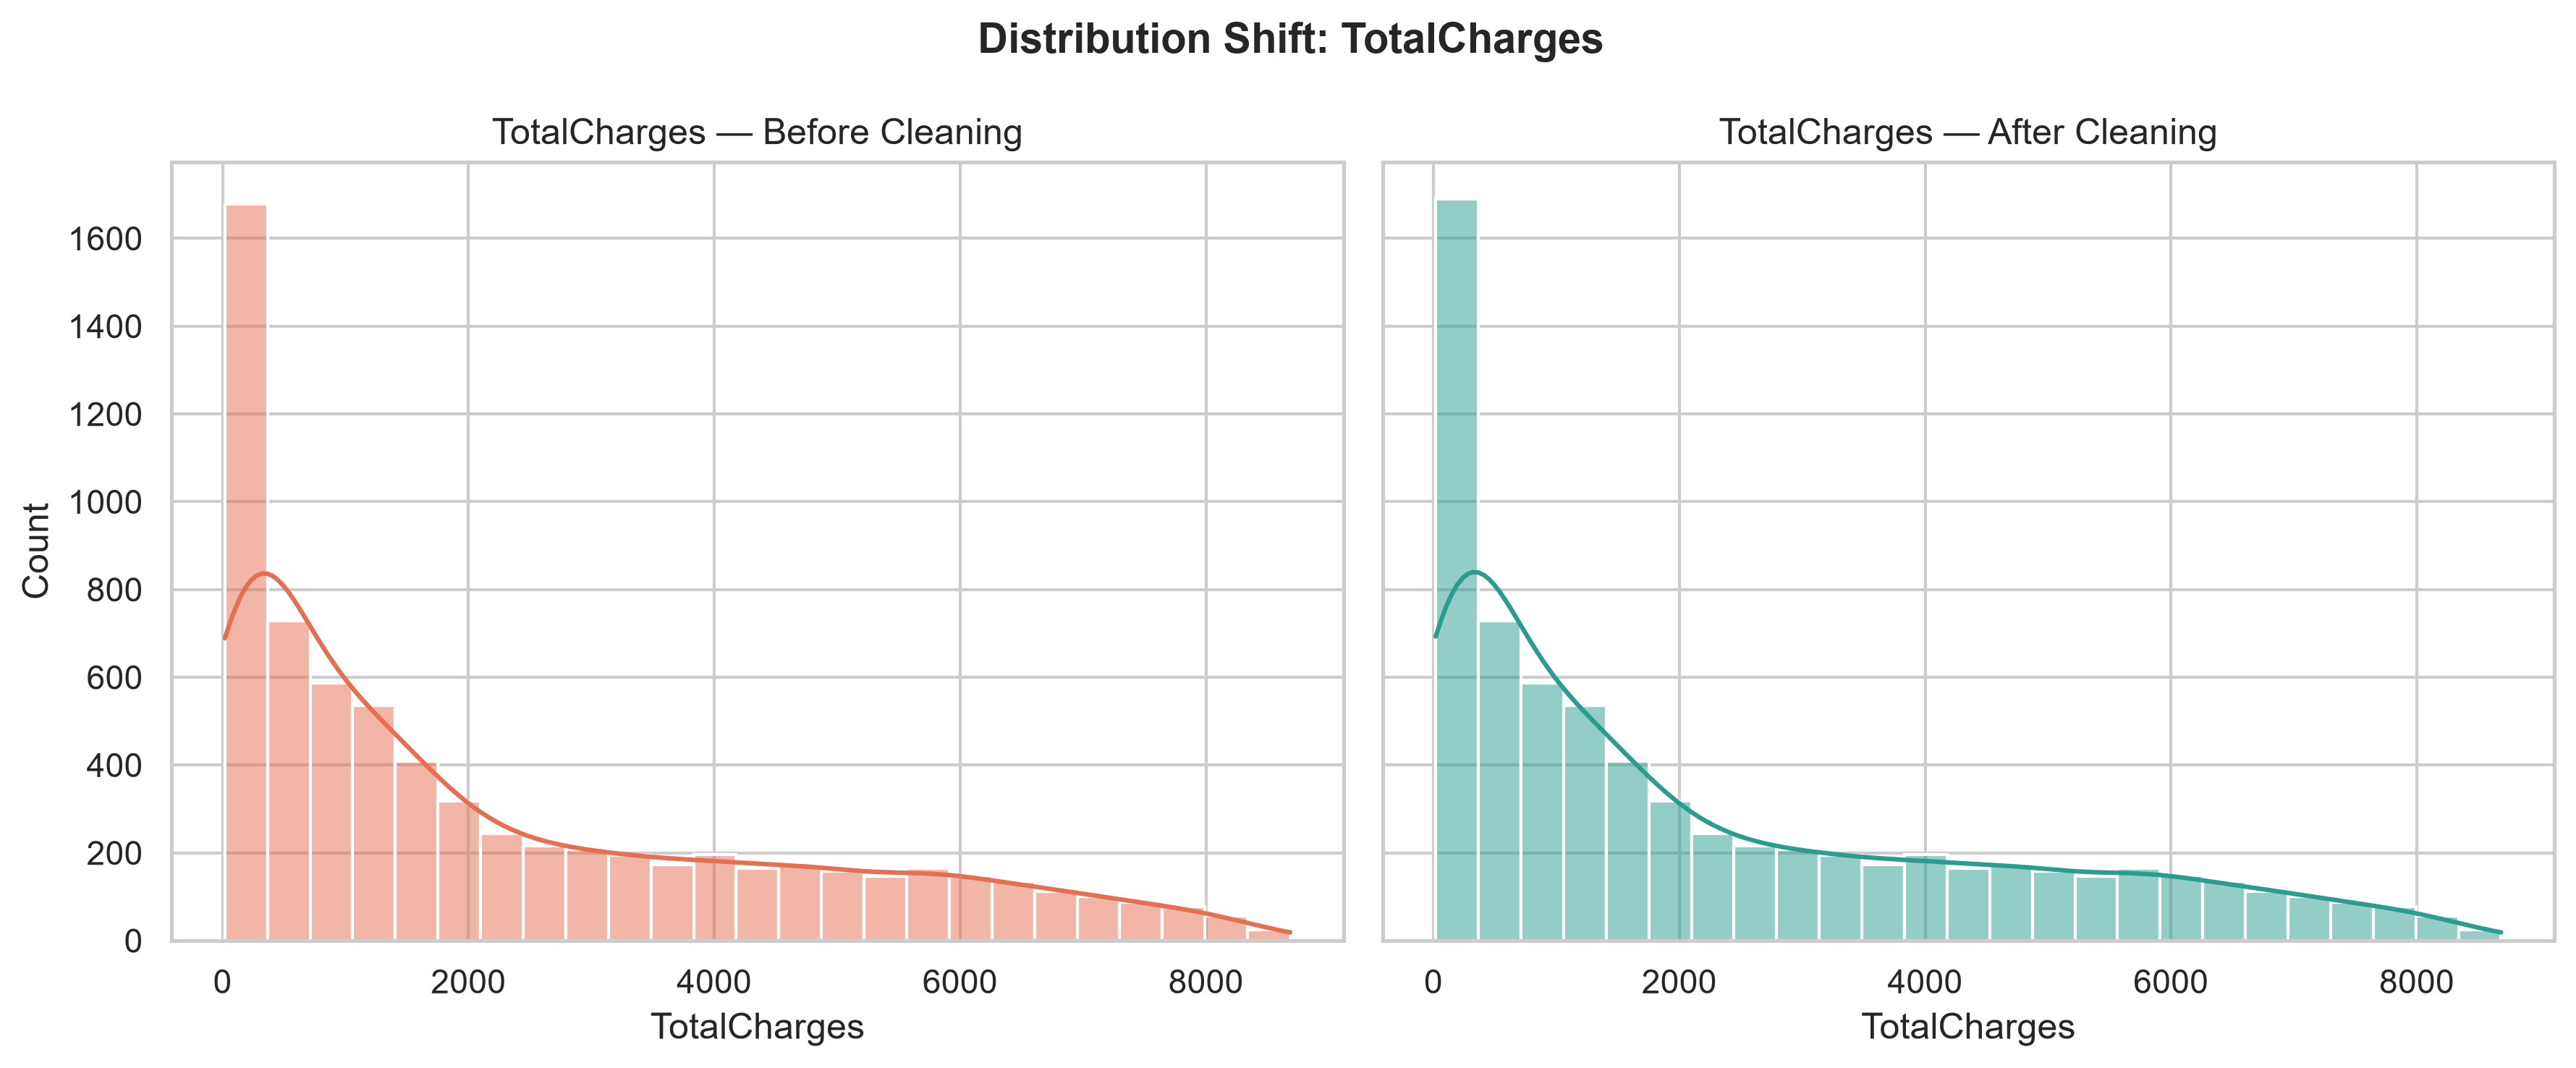

04_univariate_numeric_distributions.png


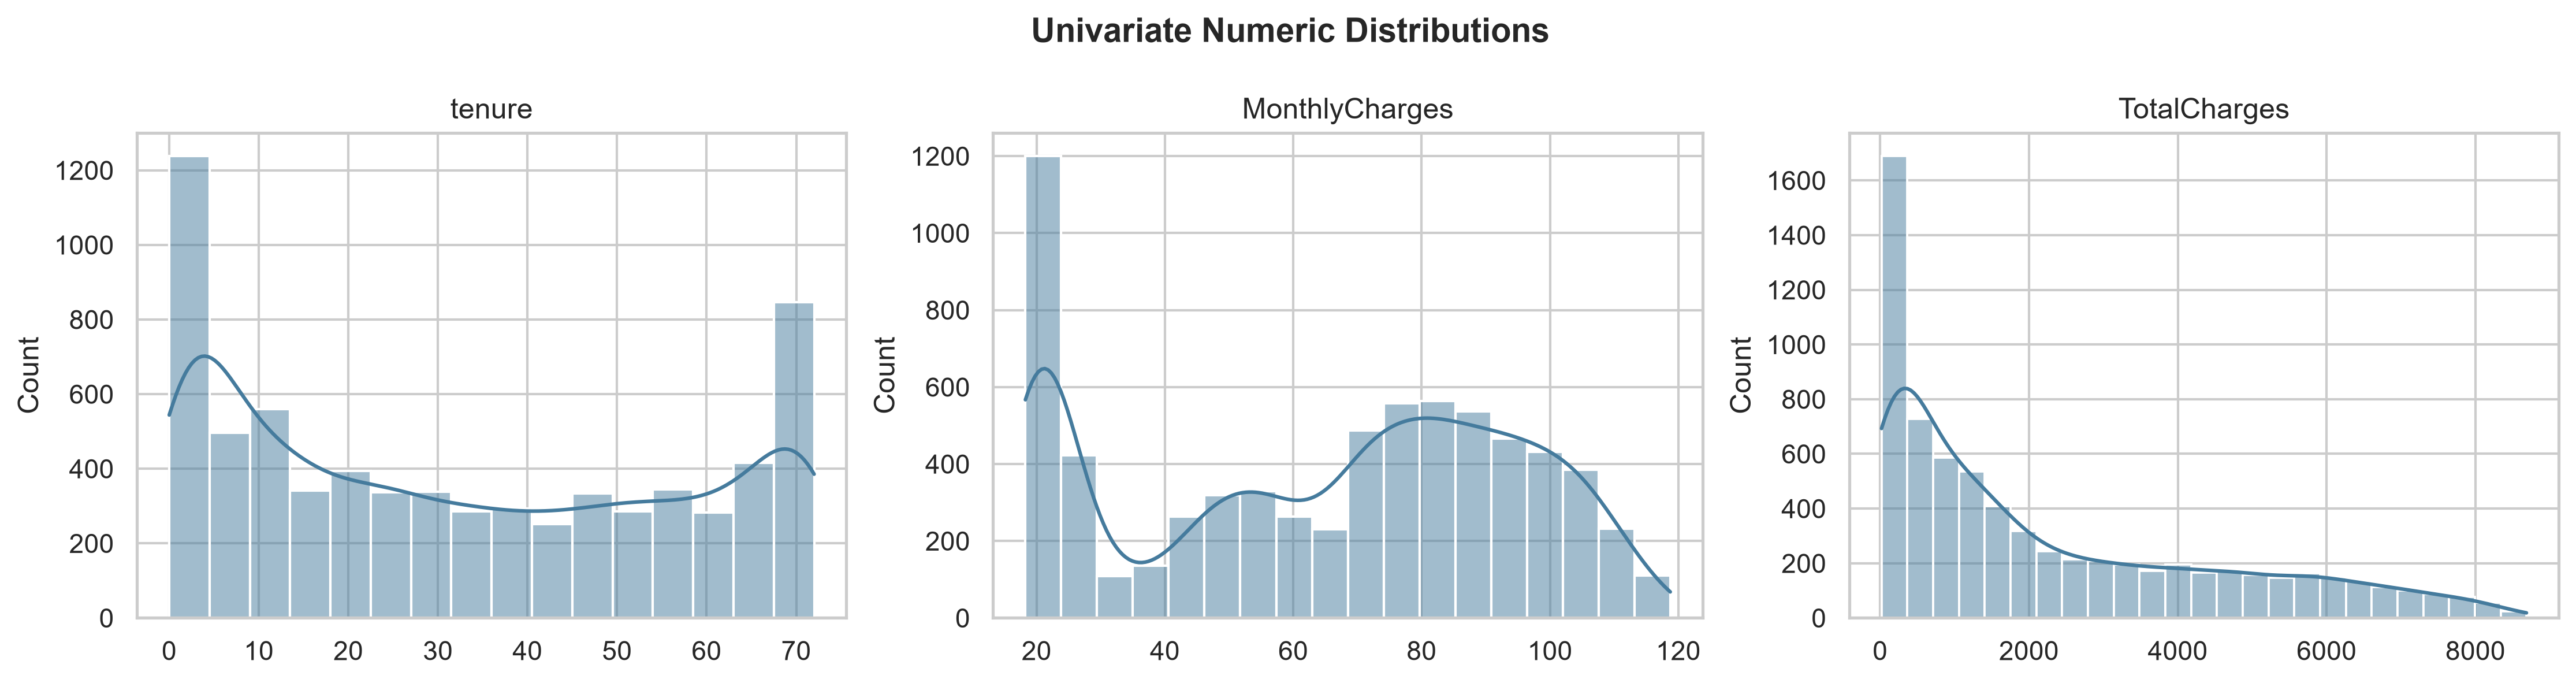

05_monthlycharges_by_contract.png


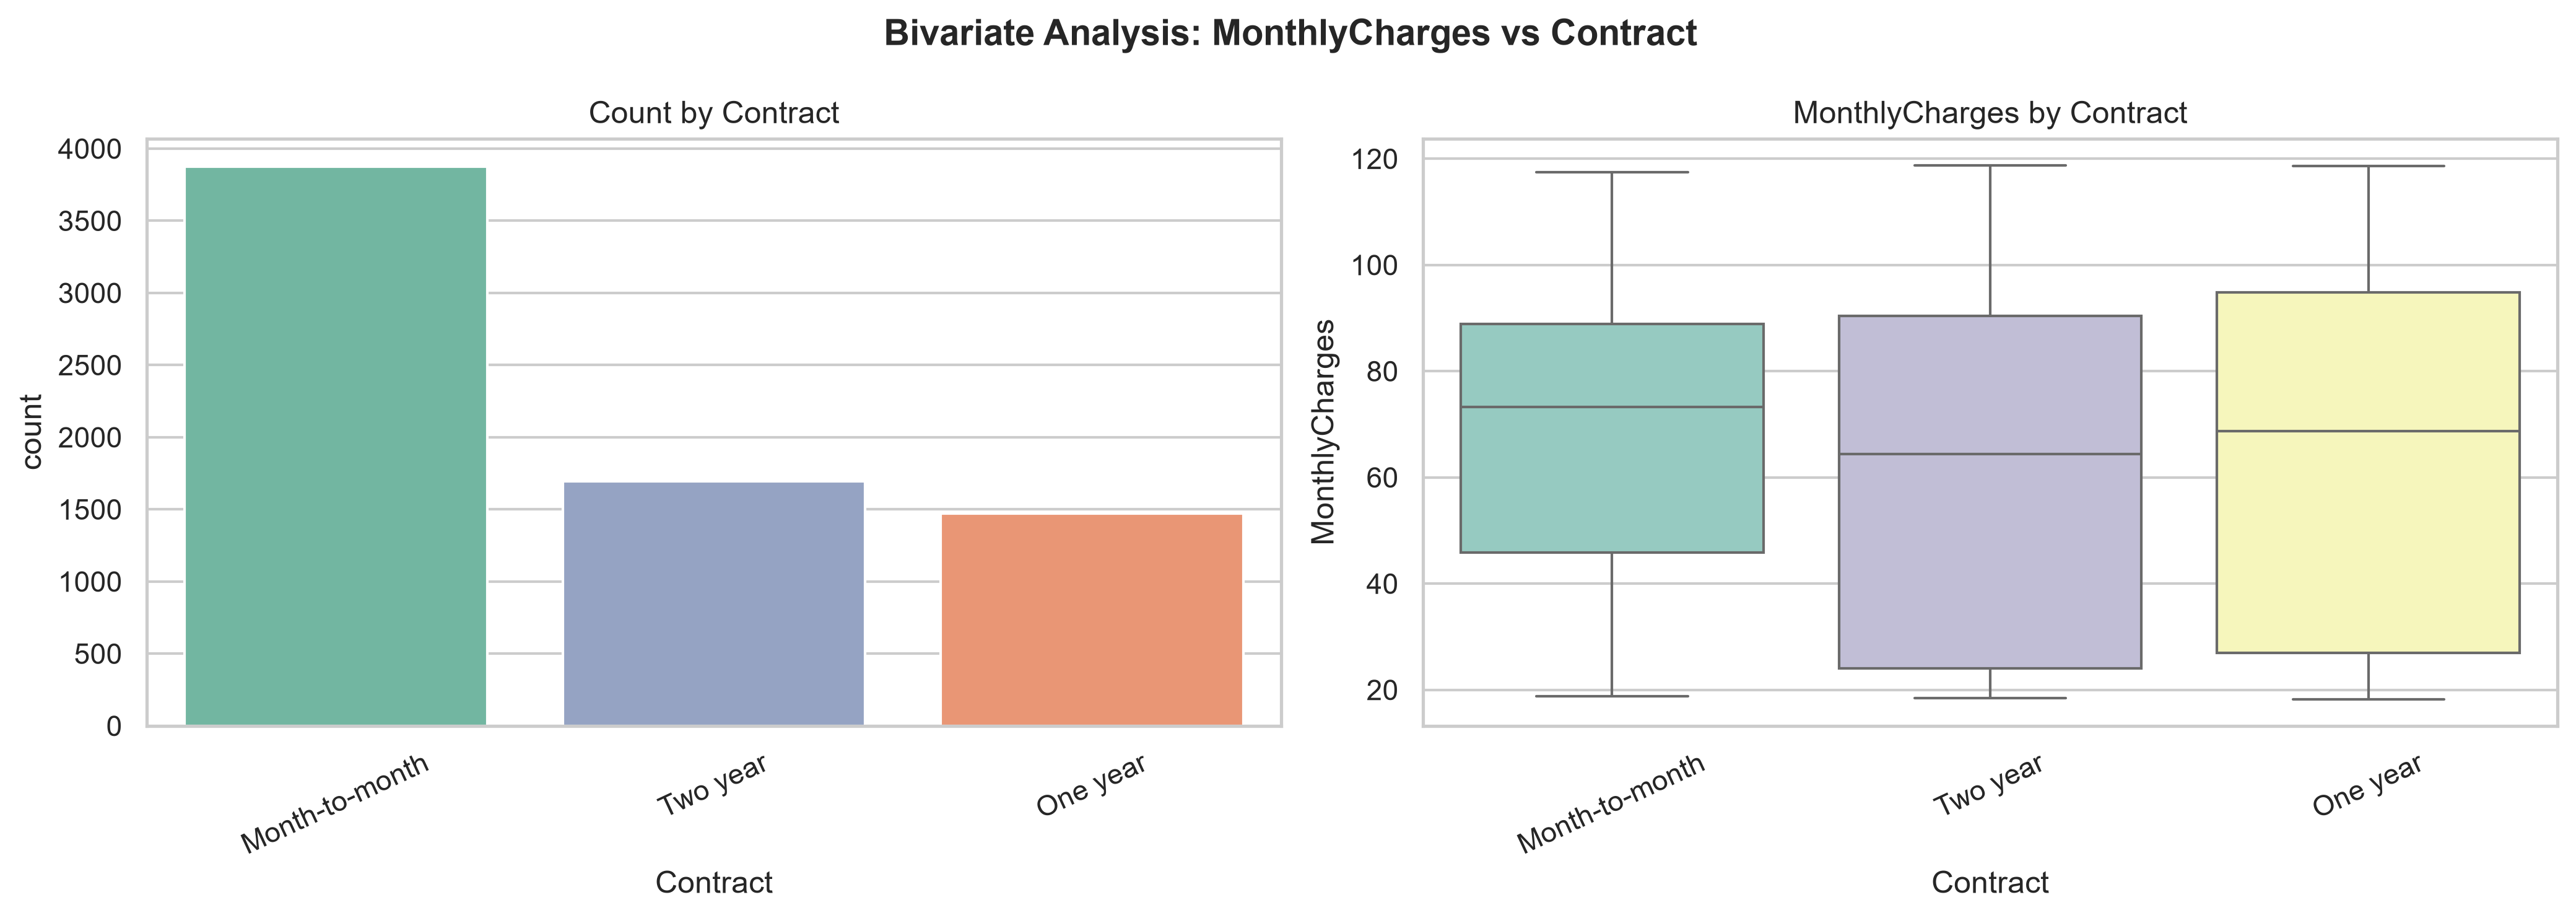

06_tenure_by_churn.png


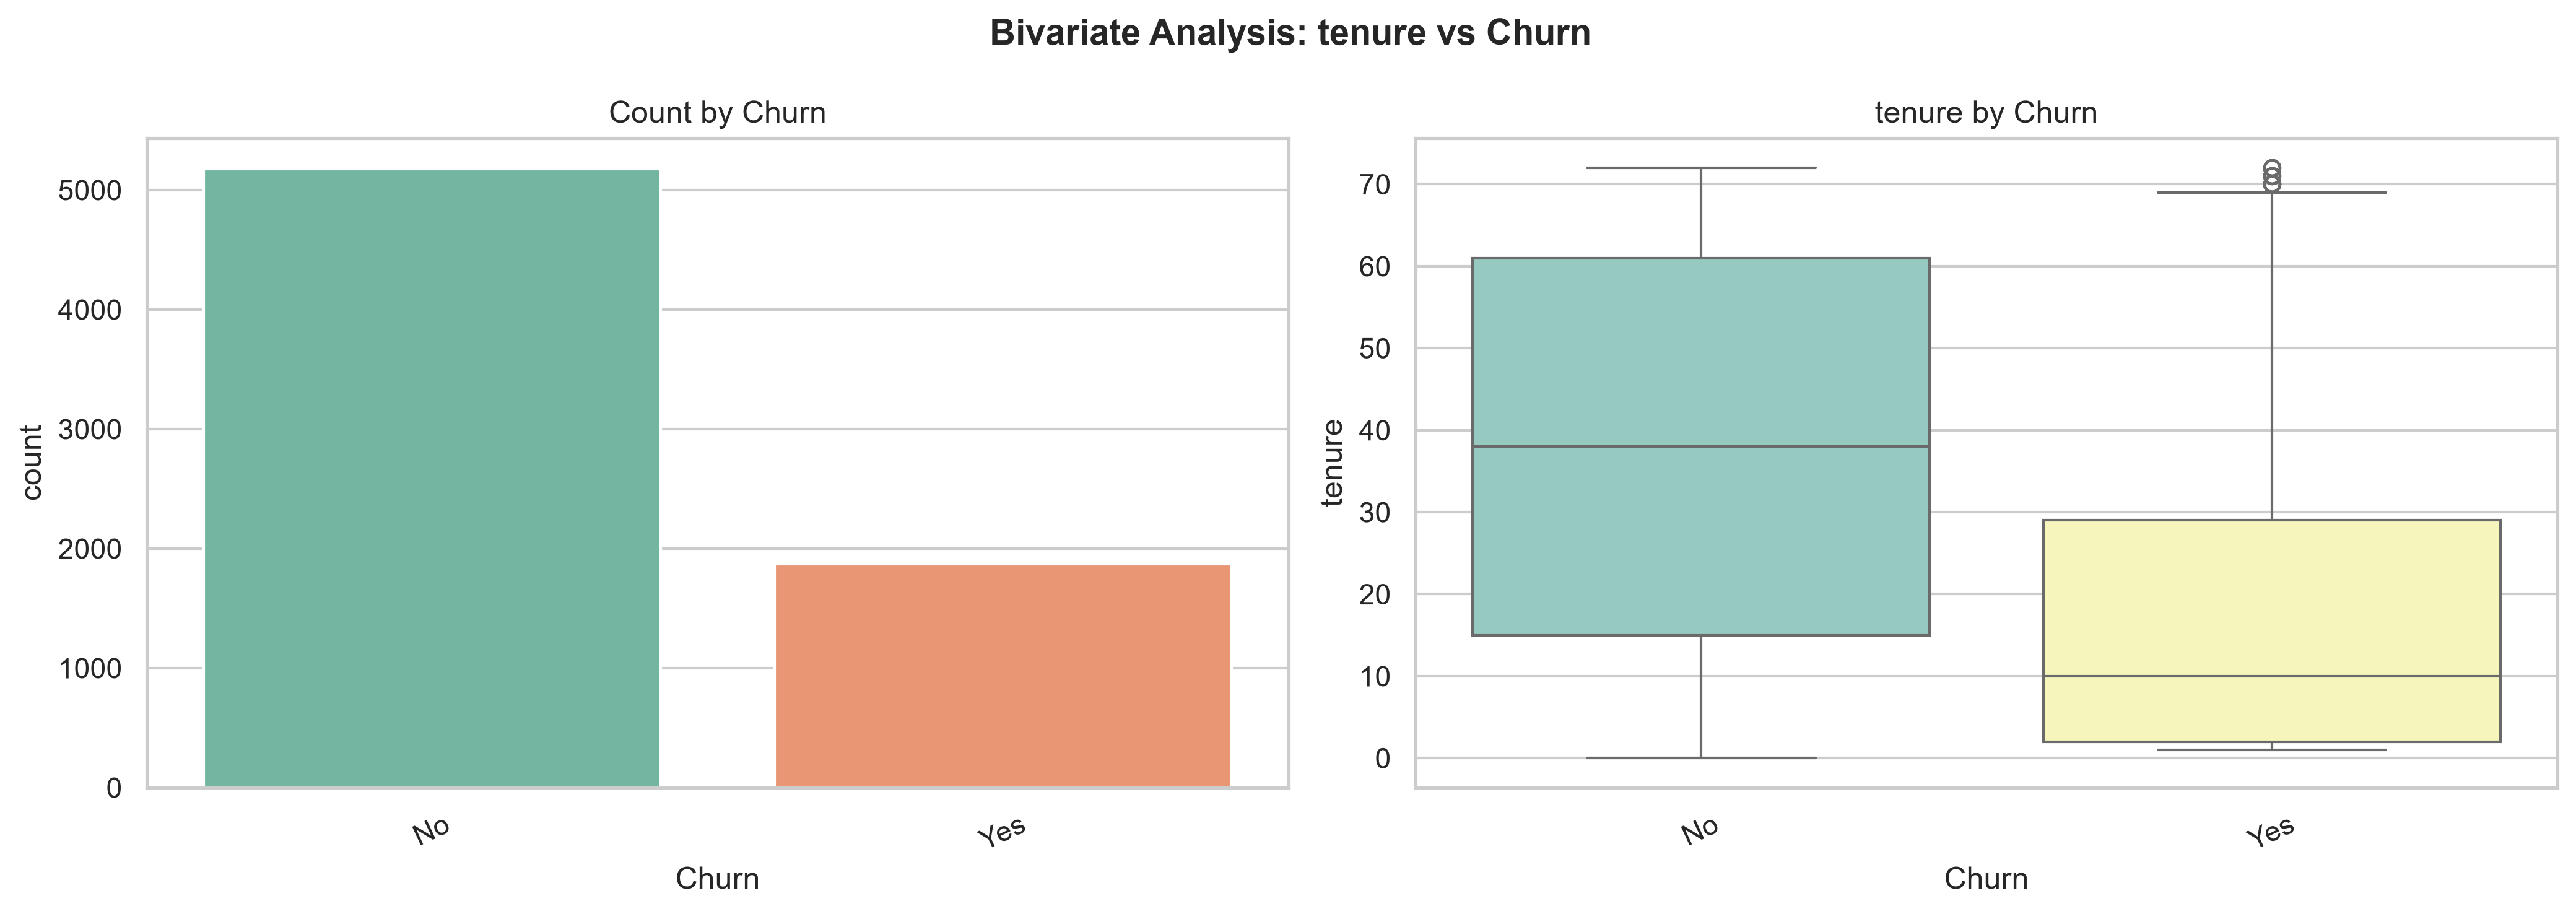

07_correlation_heatmap.png


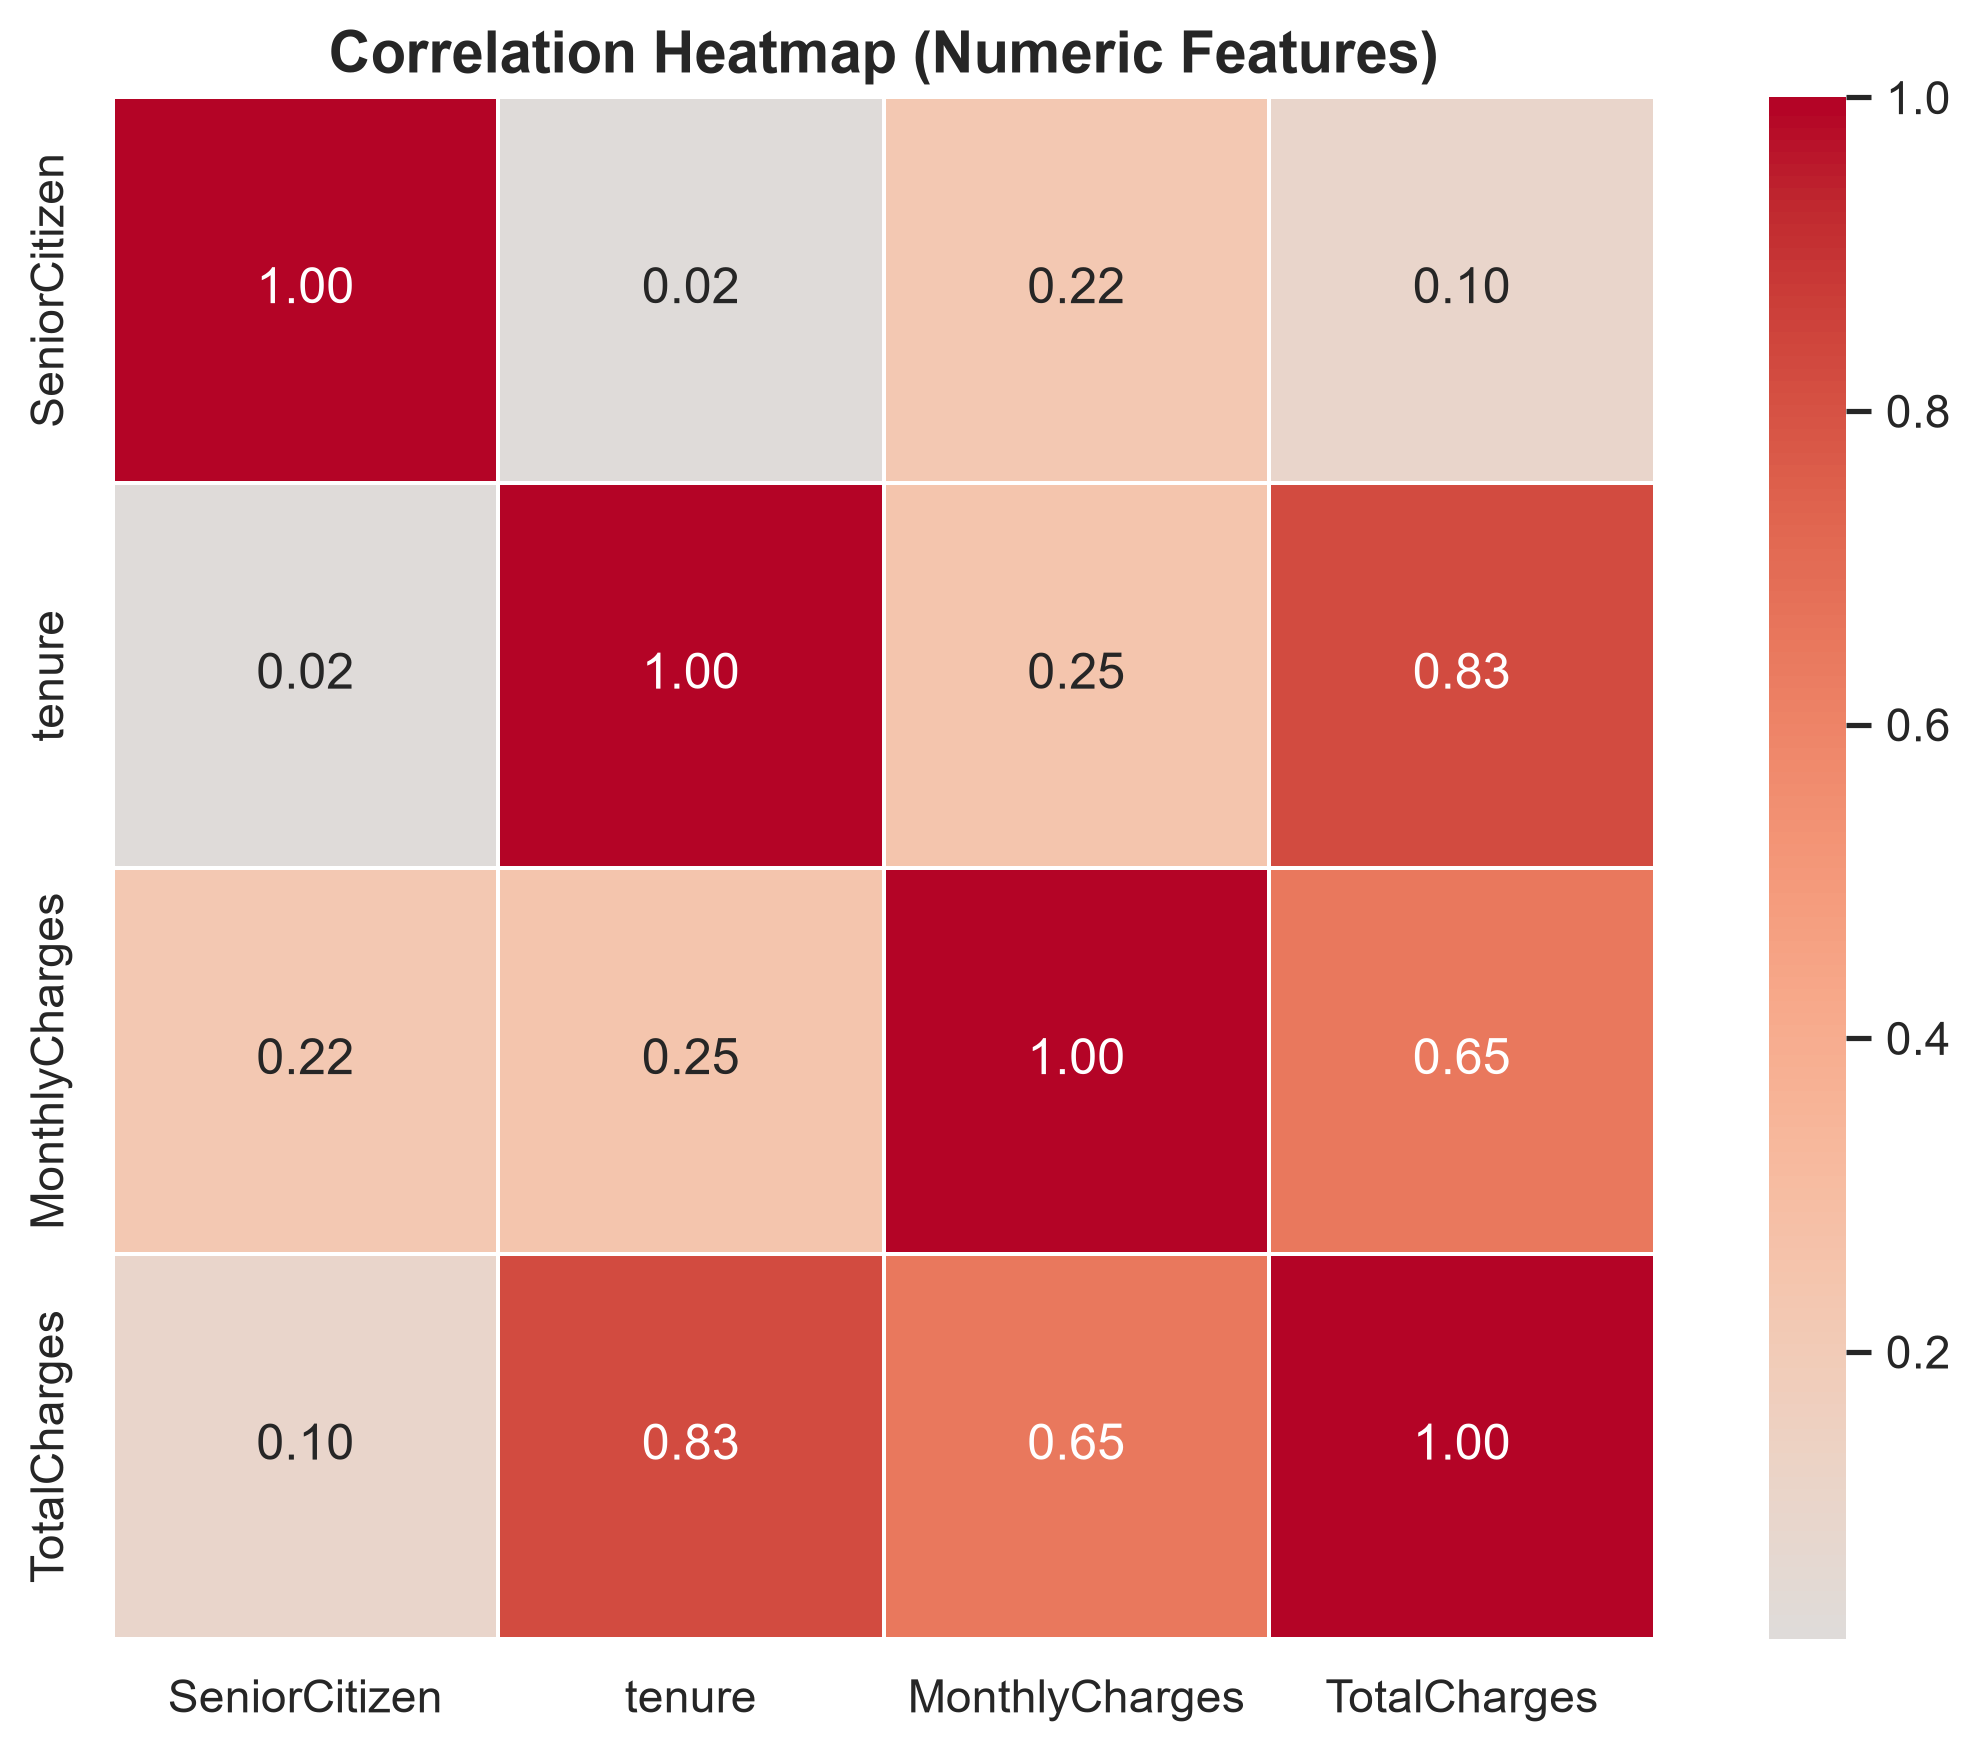

In [8]:
from IPython.display import Image, display

for fig_path in sorted(FIGURES_DIR.glob("*.png")):
    print(fig_path.name)
    display(Image(filename=str(fig_path)))

## 4. Key Findings & QA Checklist

| Check | Status |
|---|---|
| Raw data loaded (7,043 x 21) | Done |
| Hidden `TotalCharges` blanks resolved | Done (11 MNAR rows) |
| `TotalCharges` cast to float64 | Done |
| Zero unhandled nulls post-cleaning | Done |
| Outliers clipped via IQR | Done |
| Cleaned CSV saved | Done |
| 7 figures exported at 300 DPI | Done |